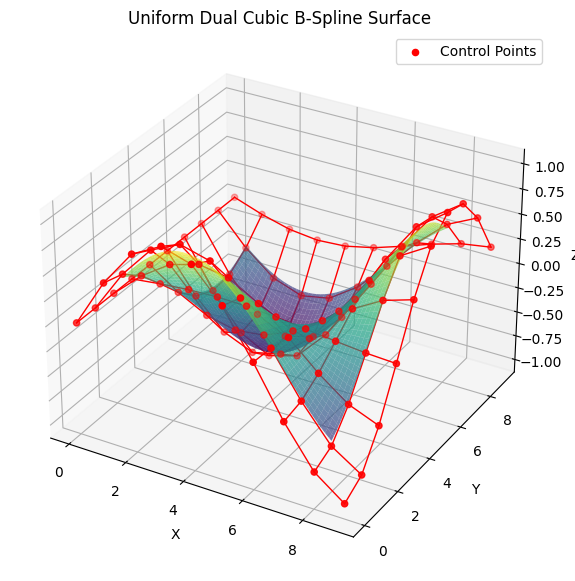

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D 플롯을 위한 모듈

# ========================================
# 1. 큐빅 B-스플라인 기저함수 정의
# ========================================
def cubic_bspline(t):
    """
    균일 큐빅 B-스플라인 기저함수를 계산하는 함수.
    
    정의 (cardinal cubic B-spline):
      - |t| < 1      : B(t) = (4 - 6t^2 + 3|t|^3) / 6
      - 1 <= |t| < 2 : B(t) = ((2 - |t|)^3) / 6
      - 그 외        : B(t) = 0
    """
    # 스칼라와 배열 모두 처리할 수 있도록 작성
    t = np.abs(t)
    if np.isscalar(t):
        if t < 1:
            return (4 - 6*t**2 + 3*t**3) / 6.0
        elif t < 2:
            return ((2 - t)**3) / 6.0
        else:
            return 0.0
    else:
        result = np.zeros_like(t, dtype=float)
        mask1 = (t < 1)
        result[mask1] = (4 - 6*t[mask1]**2 + 3*t[mask1]**3) / 6.0
        mask2 = (t >= 1) & (t < 2)
        result[mask2] = ((2 - t[mask2])**3) / 6.0
        return result

# ========================================
# 2. 제어점 격자(Control Net) 생성
# ========================================
# 제어점 개수 (nx x ny)
nx, ny = 10, 10

# x, y 좌표를 균일하게 배치 (0~9 사이)
Xc, Yc = np.meshgrid(np.linspace(0, 9, nx), np.linspace(0, 9, ny), indexing='ij')

# z 좌표는 예시로 sin, cos 함수를 이용해 변화를 주었습니다.
Zc = np.sin(0.5 * Xc) * np.cos(0.5 * Yc)

# 각 제어점을 (x,y,z) 좌표로 결합 (배열의 shape: (nx, ny, 3))
control_points = np.stack((Xc, Yc, Zc), axis=2)

# ========================================
# 3. B-Spline surface 평가 함수 정의
# ========================================
def bspline_surface(u, v, control_points):
    """
    파라미터 (u, v)에서 B-spline surface의 3D 점을 계산.
    
    S(u, v) = sum_i sum_j [ B(u - i) * B(v - j) * C[i, j] ]
    단, 제어점 C[i,j]는 control_points 배열에 있음.
    
    주의: 균일 B-스플라인이므로, u와 v의 값에 대해
          abs(u - i) < 2, abs(v - j) < 2인 경우에만 기여함.
    """
    nx, ny, _ = control_points.shape
    point = np.zeros(3)
    # 모든 제어점에 대해 기여값을 누적
    for i in range(nx):
        bu = cubic_bspline(u - i)
        if bu == 0:
            continue  # 기저함수가 0이면 다음 i로
        for j in range(ny):
            bv = cubic_bspline(v - j)
            if bv == 0:
                continue
            point += control_points[i, j] * bu * bv
    return point

# ========================================
# 4. 파라미터 영역에서 곡면 점 계산
# ========================================
# 파라미터 u, v의 정의: control point 인덱스 범위 내에서 평가하도록 함.
# 가장자리 부분은 기저함수의 지지가 완전하지 않으므로, 내부 영역을 사용합니다.
u_vals = np.linspace(1, nx - 2, 100)  # u 파라미터 (예: 1 ~ 8)
v_vals = np.linspace(1, ny - 2, 100)  # v 파라미터 (예: 1 ~ 8)
U, V = np.meshgrid(u_vals, v_vals, indexing='ij')

# 평가된 곡면 점을 저장할 배열 (shape: (100, 100, 3))
surface_points = np.zeros((len(u_vals), len(v_vals), 3))
for ui in range(len(u_vals)):
    for vi in range(len(v_vals)):
        surface_points[ui, vi] = bspline_surface(u_vals[ui], v_vals[vi], control_points)

# ========================================
# 5. 3D 시각화
# ========================================
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# (a) 제어점(컨트롤 넷) 그리기 : 산점도와 선으로 표현
ax.scatter(control_points[:,:,0], control_points[:,:,1], control_points[:,:,2],
           color='r', label='Control Points')

# 가로줄 그리기 (i 방향)
for i in range(nx):
    ax.plot(control_points[i,:,0], control_points[i,:,1], control_points[i,:,2],
            color='r', linewidth=1)
# 세로줄 그리기 (j 방향)
for j in range(ny):
    ax.plot(control_points[:,j,0], control_points[:,j,1], control_points[:,j,2],
            color='r', linewidth=1)

# (b) B-Spline 곡면 그리기
ax.plot_surface(surface_points[:,:,0], surface_points[:,:,1], surface_points[:,:,2],
                cmap='viridis', alpha=0.7, edgecolor='none')

ax.set_title("Uniform Dual Cubic B-Spline Surface")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()


Using device: cuda
Epoch 100/1000, Train Loss: -1.4974, Validation Loss: -1.4851
Epoch 200/1000, Train Loss: -1.5408, Validation Loss: -1.2629
Epoch 300/1000, Train Loss: -1.6217, Validation Loss: -1.5244
Epoch 400/1000, Train Loss: -1.6828, Validation Loss: -1.4328
Epoch 500/1000, Train Loss: -1.5989, Validation Loss: -1.5095
Epoch 600/1000, Train Loss: -1.7420, Validation Loss: -1.5662
Epoch 700/1000, Train Loss: -1.5456, Validation Loss: -1.5035
Epoch 800/1000, Train Loss: -1.7092, Validation Loss: -1.4410
Epoch 900/1000, Train Loss: -1.7631, Validation Loss: -1.3465
Epoch 1000/1000, Train Loss: -1.6989, Validation Loss: -1.3396


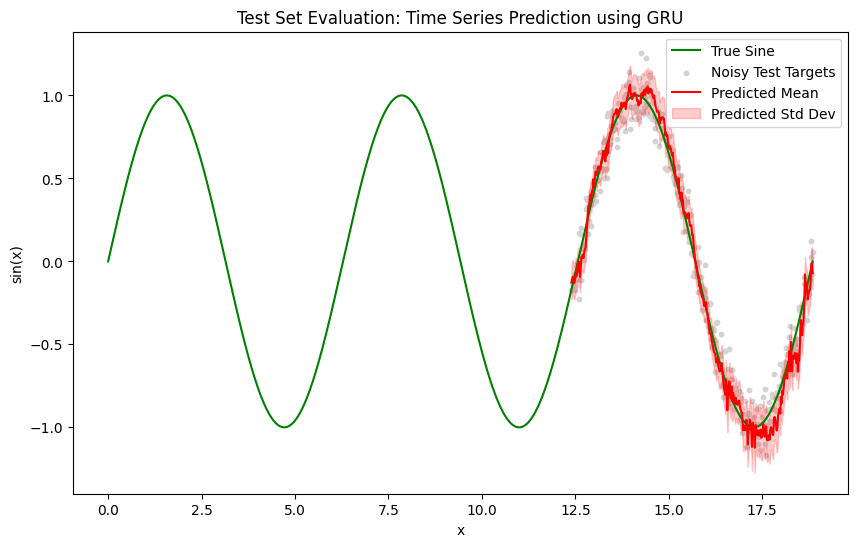

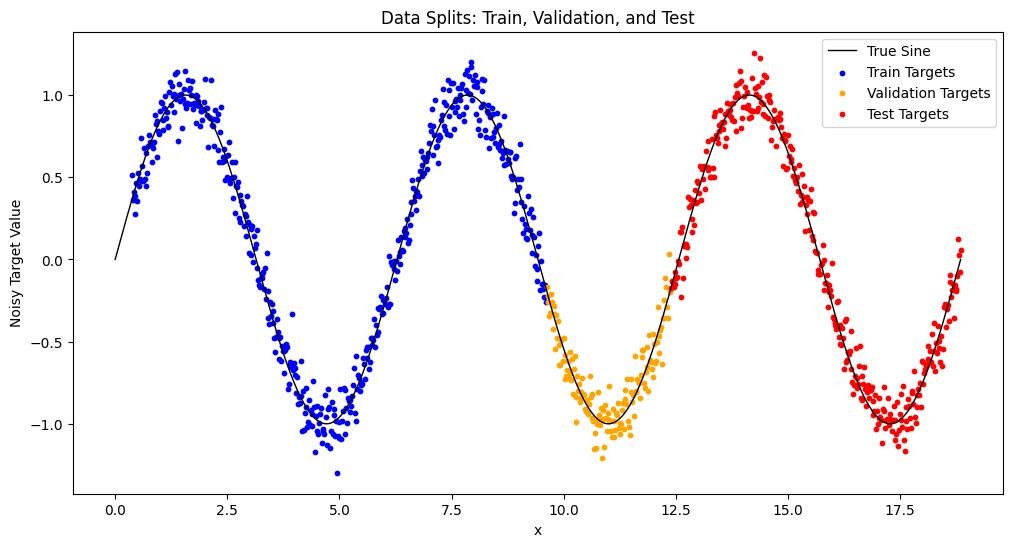

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset

# -------------------------------
# Setup: Random Seeds and Device
# -------------------------------
np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------
# Data Generation and Sequence Creation
# -------------------------------
def generate_sine_wave_data(N=1000, noise_std=0.1):
    """
    Generates a sine wave with added Gaussian noise.
    Returns:
        x: time values,
        y_true: clean sine values,
        y_noisy: sine values with added noise.
    """
    x = np.linspace(0, 6 * np.pi, N)
    y_true = np.sin(x)
    noise = np.random.normal(0, noise_std, size=y_true.shape)
    y_noisy = y_true + noise
    return x, y_true, y_noisy

def create_sequences(data, seq_length):
    """
    Creates input sequences and targets using a sliding window.
    
    Parameters:
        data (np.ndarray): The 1D input data array.
        seq_length (int): Number of consecutive points in each sequence.
    
    Returns:
        tuple: Array of sequences (inputs) and array of targets.
    """
    X_seq, Y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i : i + seq_length])
        Y_seq.append(data[i + seq_length])
    return np.array(X_seq), np.array(Y_seq)

# -------------------------------
# Custom Dataset using torch.utils.data.Dataset
# -------------------------------
class SineDataset(Dataset):
    """
    A custom dataset for sine wave sequences.
    Expects numpy arrays for inputs and targets, then converts them to torch tensors.
    """
    def __init__(self, X, Y):
        # Convert numpy arrays to torch tensors and add the feature dimension.
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (N, seq_length, 1)
        self.Y = torch.tensor(Y, dtype=torch.float32).unsqueeze(-1)  # (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# -------------------------------
# DataLoader Creation Using Subsets
# -------------------------------
def create_dataloaders(dataset, train_ratio=0.5, valid_ratio=0.15, batch_size=32):
    """
    Splits the dataset into train, validation, and test using torch.utils.data.Subset,
    and returns corresponding DataLoaders.
    
    Parameters:
        dataset (Dataset): The complete dataset.
        train_ratio (float): Proportion of data used for training.
        valid_ratio (float): Proportion of data used for validation.
        batch_size (int): Batch size for DataLoaders.
    
    Returns:
        tuple: (train_loader, valid_loader, test_loader, train_size, valid_size)
               train_size and valid_size are indices counts to help with visualization later.
    """
    num_samples = len(dataset)
    train_size = int(num_samples * train_ratio)
    valid_size = int(num_samples * valid_ratio)
    test_size = num_samples - train_size - valid_size

    # For time series, it is important to maintain the order
    train_indices = list(range(0, train_size))
    valid_indices = list(range(train_size, train_size + valid_size))
    test_indices  = list(range(train_size + valid_size, num_samples))

    train_dataset = Subset(dataset, train_indices)
    valid_dataset = Subset(dataset, valid_indices)
    test_dataset  = Subset(dataset, test_indices)

    loader_params = {
        "batch_size": batch_size,
        "shuffle": False,  # maintain order for time series forecasting
        "pin_memory": True if device.type == "cuda" else False
    }

    train_loader = DataLoader(train_dataset, **loader_params)
    valid_loader = DataLoader(valid_dataset, **loader_params)
    test_loader  = DataLoader(test_dataset, **loader_params)

    return train_loader, valid_loader, test_loader, train_size, valid_size

# -------------------------------
# Model Definition
# -------------------------------
class GRUGaussianModel(nn.Module):
    """
    GRU-based model that outputs both the predicted mean and log variance
    for modeling Gaussian uncertainty.
    """
    def __init__(self, input_size=1, hidden_size=32):
        super(GRUGaussianModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc_mean = nn.Linear(hidden_size, 1)
        self.fc_logvar = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.gru(x)
        # Use the output from the final time step for prediction.
        h_last = out[:, -1, :]
        mean = self.fc_mean(h_last)
        logvar = self.fc_logvar(h_last)
        return mean, logvar

def gaussian_nll_loss(y, mean, logvar):
    """
    Gaussian Negative Log Likelihood (NLL) loss.
    loss = 0.5 * log(variance) + 0.5 * ((y - mean)^2 / variance)
    """
    loss = 0.5 * logvar+ 0.5 * ((y - mean)**2) / torch.exp(logvar)
    return torch.mean(loss)

# -------------------------------
# Training and Evaluation Functions
# -------------------------------
def train_model(model, optimizer, train_loader, valid_loader, epochs=1000, print_every=100):
    """
    Train the model with periodic validation evaluation.
    """
    criterion = nn.GaussianNLLLoss(full=False,reduction='mean')
   
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch_X, batch_Y in train_loader:
            # Move data to device.
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            optimizer.zero_grad()
            pred_mean, pred_logvar = model(batch_X)
            # loss = gaussian_nll_loss(batch_Y, pred_mean, pred_logvar)
            variance = torch.exp(pred_logvar)
            loss = criterion(pred_mean, batch_Y, variance)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        
        model.eval()
        valid_losses = []
        with torch.no_grad():
            for batch_X, batch_Y in valid_loader:
                batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
                pred_mean, pred_logvar = model(batch_X)
                # loss = gaussian_nll_loss(batch_Y, pred_mean, pred_logvar)
                variance = torch.exp(pred_logvar)
                loss = criterion(pred_mean, batch_Y, variance)
                valid_losses.append(loss.item())
        
        if (epoch + 1) % print_every == 0:
            avg_train_loss = np.mean(train_losses)
            avg_valid_loss = np.mean(valid_losses)
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

def evaluate_model(model, test_loader):
    """
    Evaluate the model on the test set, returning the predicted mean,
    predicted standard deviation, and true targets.
    """
    model.eval()
    all_preds, all_stds, all_targets = [], [], []
    with torch.no_grad():
        for batch_X, batch_Y in test_loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            pred_mean, pred_logvar = model(batch_X)
            pred_std = torch.sqrt(torch.exp(pred_logvar))
            all_preds.append(pred_mean.cpu().numpy())
            all_stds.append(pred_std.cpu().numpy())
            all_targets.append(batch_Y.cpu().numpy())
    
    pred_mean_test = np.concatenate(all_preds).flatten()
    pred_std_test = np.concatenate(all_stds).flatten()
    targets_test = np.concatenate(all_targets).flatten()
    return pred_mean_test, pred_std_test, targets_test

# -------------------------------
# Visualization Functions
# -------------------------------
def plot_predictions(x, y_true, x_test, targets_test, pred_mean_test, pred_std_test):
    """
    Plot the true sine wave, noisy test targets, and the model predictions with uncertainty.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(x, y_true, label="True Sine", color="green")
    plt.scatter(x_test, targets_test, label="Noisy Test Targets", color="lightgrey", s=10)
    plt.plot(x_test, pred_mean_test, label="Predicted Mean", color="red")
    plt.fill_between(x_test,
                     pred_mean_test - pred_std_test,
                     pred_mean_test + pred_std_test,
                     color="red", alpha=0.2, label="Predicted Std Dev")
    plt.xlabel("x")
    plt.ylabel("sin(x)")
    plt.title("Test Set Evaluation: Time Series Prediction using GRU")
    plt.legend()
    plt.show()

def plot_data_splits(x, y_true, y_noisy, train_size, valid_size, seq_length):
    """
    Visualizes data splits (train, validation, and test) based on sliding-window targets.
    """
    x_train = x[seq_length : train_size + seq_length]
    x_val   = x[train_size + seq_length : train_size + valid_size + seq_length]
    x_test_vis = x[train_size + valid_size + seq_length :]
    
    y_train = y_noisy[seq_length : train_size + seq_length]
    y_val   = y_noisy[train_size + seq_length : train_size + valid_size + seq_length]
    y_test_vis = y_noisy[train_size + valid_size + seq_length :]
    
    plt.figure(figsize=(12, 6))
    plt.plot(x, y_true, label="True Sine", color="black", linewidth=1)
    plt.scatter(x_train, y_train, label="Train Targets", color="blue", s=10)
    plt.scatter(x_val, y_val, label="Validation Targets", color="orange", s=10)
    plt.scatter(x_test_vis, y_test_vis, label="Test Targets", color="red", s=10)
    plt.xlabel("x")
    plt.ylabel("Noisy Target Value")
    plt.title("Data Splits: Train, Validation, and Test")
    plt.legend()
    plt.show()

# -------------------------------
# Main Function
# -------------------------------
def main():
    # Parameters
    N = 1000
    seq_length = 20
    epochs = 1000
    batch_size = 32
    
    # Generate data and create sliding window sequences
    x, y_true, y_noisy = generate_sine_wave_data(N)
    X_seq, Y_seq = create_sequences(y_noisy, seq_length)
    
    # Create the complete dataset using torch.utils.data.Dataset
    dataset = SineDataset(X_seq, Y_seq)
    
    # Split the dataset into train, validation, and test subsets
    train_loader, valid_loader, test_loader, train_size, valid_size = create_dataloaders(
        dataset, train_ratio=0.5, valid_ratio=0.15, batch_size=batch_size
    )
    
    # Initialize the model and move it to the device (GPU if available)
    model = GRUGaussianModel(input_size=1, hidden_size=32).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    # Train the model
    train_model(model, optimizer, train_loader, valid_loader, epochs=epochs, print_every=100)
    
    # Evaluate the model on the test set
    pred_mean_test, pred_std_test, targets_test = evaluate_model(model, test_loader)
    
    # Map test predictions to their corresponding x-values
    x_test = x[train_size + valid_size + seq_length:]
    
    # Plot predictions with uncertainty bounds
    plot_predictions(x, y_true, x_test, targets_test, pred_mean_test, pred_std_test)
    
    # Visualize data splits (train, validation, test)
    plot_data_splits(x, y_true, y_noisy, train_size, valid_size, seq_length)

if __name__ == "__main__":
    main()


In [49]:
from graphviz import Digraph

# Graphviz 다이어그램 생성 (노드와 엣지 정의)
dot = Digraph(comment="Network Framework Diagram", format="png")

# -----------------------------
# Model Network 다이어그램 구성
# -----------------------------
# 입력 노드: 차량 파라미터 9개
model_input = "vx, vy, r,w_s, mu, delta,sa_f, sa_r, sr"
dot.node("ModelInput", "Input\n(" + model_input + ")", shape="box", style="filled", fillcolor="lightblue")

# Model Network 내부 레이어 (예시로 하나의 블록으로 표시)
dot.node("ModelNet", "Model Network", shape="box")

# 출력 노드: 타이어 힘 4개
model_output = "Fxr, Fxf, Fyr, Fyf"
dot.node("Model Output", "Output\n(" + model_output + ")", shape="box", style="filled", fillcolor="lightgreen")

# Model Network 간 연결
dot.edge("ModelInput", "ModelNet", label="")
dot.edge("ModelNet", "Model Output", label="")

# -----------------------------
# Noise Network 다이어그램 구성
# -----------------------------
# 입력 노드: 시계열 데이터 (10개 feature)
noise_input = "vx, vy, r, w_s,mu, delta, Iq,ax_imu, ay_imu, r_imu"
dot.node("NoiseInput", "Time-Series Input\n(" + noise_input + ")", shape="box", style="filled", fillcolor="lightblue")

# Noise Network 내부: LSTM + FC
dot.node("NoiseNet", "Noise Network", shape="box")

# 출력 노드: 노이즈 공분산 행렬 관련 파라미터 3개
noise_output = "Q, R, P0"
dot.node("NoiseOutput", " Output\n(" + noise_output + ")", shape="box", style="filled", fillcolor="lightgreen")

# Noise Network 간 연결
dot.edge("NoiseInput", "NoiseNet", label="")
dot.edge("NoiseNet", "NoiseOutput", label="")

# -----------------------------
# 다이어그램 렌더링 및 출력
# -----------------------------
# 파일 이름은 "network_framework.png"로 저장됩니다.
dot.render("network_framework", view=True)


'network_framework.png'

UKF 시뮬레이션 시작!!


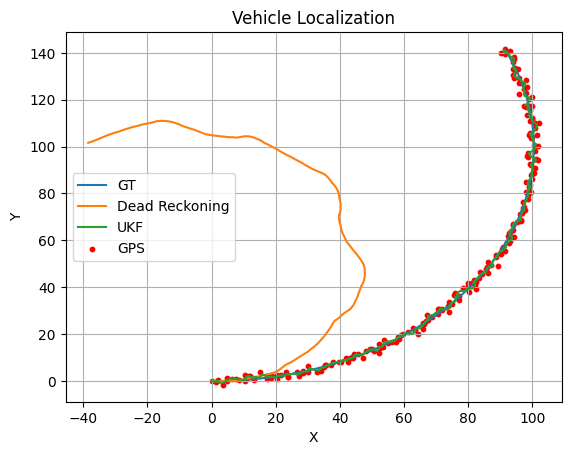

In [18]:
import numpy as np
import math
import matplotlib.pyplot as plt

#---------------------------
# 전역 상수 정의
#---------------------------
DT = 0.1          # 시간 간격 (초)
SIM_TIME = 20.0   # 총 시뮬레이션 시간 (초)

# UKF 스케일링 파라미터
ALPHA = 0.01     # (또는 필요에 따라 0.1 등으로 조정)
KAPPA = 0         # 보통 0 혹은 3 - n_x 사용
BETA = 2          # 가우시안 분포에 대해 최적은 2

# 상태 벡터 차원 (예: [x, y, yaw, v])
NX = 4

# 프로세스 노이즈 공분산 (4x4)
Q = np.diag([0.1, 0.1, 0.1, 0.1])

# 관측 노이즈 공분산 (측정: [x, y], 2x2)
R = np.diag([1.0, 1.0])

# GPS 노이즈 (관측 시 사용, Cholesky 분해)
GPS_NOISE = np.linalg.cholesky(R)

# 입력(제어) 노이즈 공분산 (2x2)
INPUT_NOISE = np.diag([1.0, 1.0])

#---------------------------
# 유틸리티 함수: 각 정규화
#---------------------------
def normalize_angle(angle):
    """
    입력 각도를 -pi ~ pi 범위로 정규화.
    """
    return (angle + np.pi) % (2 * np.pi) - np.pi

#---------------------------
# 시스템 모델 관련 함수
#---------------------------
def motion_model(x, u):
    """
    [상태 전이 모델]
    상태 x = [x, y, theta, v] 를 u = [v, yaw_rate] 제어 입력을 사용하여 dt만큼 전파.
    """
    new_x = np.zeros((4, 1))
    theta = x[2, 0]
    v = u[0, 0]        # 제어 입력에서 속도 사용
    yaw_rate = u[1, 0]   # 제어 입력에서 회전 속도 사용

    new_x[0, 0] = x[0, 0] + v * math.cos(theta) * DT
    new_x[1, 0] = x[1, 0] + v * math.sin(theta) * DT
    new_theta = theta + yaw_rate * DT
    new_x[2, 0] = normalize_angle(new_theta)  # 각도를 정규화
    new_x[3, 0] = v  # 속도는 제어 입력 그대로 반영
    
    return new_x

def observation_model(x):
    """
    [관측 모델]
    상태 벡터 x 에서 위치 x와 y ([x, y]) 만을 관측.
    """
    z = np.array([[x[0, 0]], [x[1, 0]]])
    return z

#---------------------------
# UKF 관련 함수
#---------------------------
def generate_sigma_points(xEst, PEst, gamma):
    """
    [Sigma 점 생성]
    주어진 상태 추정치 xEst와 공분산 PEst를 사용하여 sigma 점들을 생성.
    
    xEst: (n x 1) 상태 추정치
    PEst: (n x n) 공분산 행렬
    gamma: 스케일링 인자 (sqrt(n + lambda))
    
    반환: (n x (1+2*n)) sigma 점 행렬
    """
    sigma = xEst.copy()
    # Cholesky 분해를 사용하여 제곱근 행렬 계산 (실제값 사용)
    Psqrt = np.linalg.cholesky(PEst)
    n = xEst.shape[0]
    
    # 양의 방향 sigma 점 추가
    for i in range(n):
        sigma = np.hstack((sigma, xEst + gamma * Psqrt[:, i:i+1]))
    # 음의 방향 sigma 점 추가
    for i in range(n):
        sigma = np.hstack((sigma, xEst - gamma * Psqrt[:, i:i+1]))
        
    return sigma

def calc_sigma_covariance(x, sigma, wc, Pi):
    """
    [공분산 계산]
    주어진 평균 x와 sigma 점들(sigma)을 사용하여 공분산 행렬을 계산.
    wc: 가중치 (1 x num_sigma) 벡터
    Pi: 초기 공분산 (예: 프로세스 혹은 관측 노이즈 공분산)
    """
    nSigma = sigma.shape[1]
    d = sigma - x
    # 상태 벡터 차원이 3 이상이면 3번째 원소(theta)의 정규화를 수행
    if d.shape[0] > 2:
        d[2, :] = (d[2, :] + np.pi) % (2 * np.pi) - np.pi
    
    P = Pi.copy()
    for i in range(nSigma):
        P = P + wc[0, i] * d[:, i:i+1] @ d[:, i:i+1].T
    return P


def predict_sigma_motion(sigma, u):
    """
    [예측 단계: sigma 점에 대한 상태 전파]
    각 sigma 점에 대해 motion_model을 적용하여 상태를 예측.
    
    sigma: (n x num_sigma) sigma 점들
    u: (2 x 1) 제어 입력
    """
    nSigma = sigma.shape[1]
    sigma_pred = np.zeros_like(sigma)
    for i in range(nSigma):
        sigma_point = sigma[:, i:i+1]
        sigma_pred[:, i:i+1] = motion_model(sigma_point, u)
    return sigma_pred

def predict_sigma_observation(sigma):
    """
    [관측 예측: sigma 점에 대한 관측 값 계산]
    각 sigma 점에 대해 observation_model을 적용하여 관측 공간에서의 sigma 점들을 계산.
    
    sigma: (n x num_sigma) sigma 점들
    반환: (2 x num_sigma) 관측 sigma 점들
    """
    nSigma = sigma.shape[1]
    z_sigma = np.zeros((2, nSigma))
    for i in range(nSigma):
        sigma_point = sigma[:, i:i+1]
        z_sigma[:, i:i+1] = observation_model(sigma_point)
    return z_sigma

def calc_pxz(sigma, xPred, z_sigma, zb, wc):
    """
    [상태-관측 Cross 공분산 계산]
    각 sigma 점에 대한 상태와 관측 값의 차이를 이용하여 cross 공분산을 계산.
    
    sigma: (n x num_sigma) 상태 sigma 점들
    xPred: (n x 1) 예측된 상태 평균
    z_sigma: (m x num_sigma) 각 sigma 점에 대한 관측 예측 값
    zb: (m x 1) 관측 예측 평균 (관측 공간)
    wc: (1 x num_sigma) 가중치 벡터
    """
    nSigma = sigma.shape[1]
    Pxz = np.zeros((sigma.shape[0], z_sigma.shape[0]))
    for i in range(nSigma):
        dx = sigma[:, i:i+1] - xPred
        # 상태의 회전각(theta, 인덱스 2) 정규화
        dx[2, 0] = normalize_angle(dx[2, 0])
        dz = z_sigma[:, i:i+1] - zb
        Pxz = Pxz + wc[0, i] * (dx @ dz.T)
    return Pxz

def ukf_estimation(xEst, PEst, z, u, wm, wc, gamma):
    """
    [UKF 추정 단계]
    상태 예측 및 관측 업데이트를 통해 상태를 추정.
    
    xEst: (n x 1) 이전 상태 추정치
    PEst: (n x n) 이전 공분산
    z: (m x 1) 관측값
    u: (2 x 1) 제어 입력 (업데이트 시 노이즈가 반영된 입력 사용)
    wm, wc: UKF 가중치
    gamma: 스케일링 인자
    """
    # 예측 단계
    sigma = generate_sigma_points(xEst, PEst, gamma)
    sigma = predict_sigma_motion(sigma, u)
    xPred = (wm @ sigma.T).T  # 상태 예측 평균 계산
    PPred = calc_sigma_covariance(xPred, sigma, wc, Q)  # 상태 공분산 예측 (프로세스 노이즈 Q 추가)
    
    # 업데이트 단계
    zPred = observation_model(xPred)
    y = z - zPred  # 잔차(residual)
    
    # 관측 업데이트: 예측된 상태와 공분산을 사용하여 sigma 점 재생성 (혹은 예측 단계의 sigma 점 재사용 가능)
    sigma = generate_sigma_points(xPred, PPred, gamma)
    z_sigma = predict_sigma_observation(sigma)
    zb = (wm @ z_sigma.T).T
    st = calc_sigma_covariance(zb, z_sigma, wc, R)
    Pxz = calc_pxz(sigma, xPred, z_sigma, zb, wc)
    K = Pxz @ np.linalg.inv(st)
    xEst = xPred + K @ y
    PEst = PPred - K @ st @ K.T

    # 상태 업데이트 후, 회전각(theta) 정규화
    xEst[2, 0] = normalize_angle(xEst[2, 0])
    
    return xEst, PEst

#---------------------------
# 관측 및 입력 생성 함수
#---------------------------
def observation(xTrue, xd, u):
    """
    [관측 함수]
    실제 상태 xTrue를 업데이트하고 노이즈를 추가하여 관측값 z를 생성.
    Dead Reckoning을 위한 상태 xd도 노이즈가 반영된 입력으로 업데이트.
    
    반환: 업데이트된 xTrue, 관측값 z, Dead Reckoning 상태 xd, 노이즈가 반영된 입력 ud
    """
    xTrue = motion_model(xTrue, u)
    z = observation_model(xTrue) + GPS_NOISE @ np.random.randn(2, 1)  # GPS 노이즈 추가
    ud = u + INPUT_NOISE @ np.random.randn(2, 1)  # 입력 노이즈 추가
    xd = motion_model(xd, ud)  # Dead Reckoning 업데이트
    return xTrue, z, xd, ud

def calc_input():
    """
    [제어 입력 생성]
    일정한 속도와 회전 속도를 가지는 제어 입력 생성.
    
    반환: u (2x1 벡터: [속도, 회전율])
    """
    v = 10.0       # [m/s]
    yawRate = 0.1  # [rad/s]
    u = np.array([[v, yawRate]]).T
    return u

def setup_ukf(nx):
    """
    [UKF 파라미터 및 가중치 설정]
    nx: 상태 차원
    반환: wm, wc (가중치), gamma (스케일링 인자)
    """
    lamb = ALPHA ** 2 * (nx + KAPPA) - nx
    wm = [lamb / (lamb + nx)]
    wc = [(lamb / (lamb + nx)) + (1 - ALPHA ** 2 + BETA)]
    for i in range(2 * nx):
        wm.append(1.0 / (2 * (nx + lamb)))
        wc.append(1.0 / (2 * (nx + lamb)))
    gamma = math.sqrt(nx + lamb)
    
    wm = np.array([wm])  # (1 x num_sigma)
    wc = np.array([wc])
    
    return wm, wc, gamma

#---------------------------
# 메인 함수: 시뮬레이션 실행 및 결과 플로팅
#---------------------------
def main():
    print("UKF 시뮬레이션 시작!!")
    
    # 초기 상태 설정
    xEst = np.zeros((NX, 1))    # UKF 추정 상태
    xTrue = np.zeros((NX, 1))   # 실제 상태
    PEst = np.eye(NX)           # 초기 공분산
    xDR = np.zeros((NX, 1))     # Dead Reckoning 상태
    
    wm, wc, gamma = setup_ukf(NX)
    
    # 데이터 저장용 히스토리 초기화
    hxEst = xEst.copy()
    hxTrue = xTrue.copy()
    hxDR = xDR.copy()
    hz = np.zeros((2, 1))
    
    time = 0.0
    while time <= SIM_TIME:
        time += DT
        
        # 제어 입력 계산
        u = calc_input()
        
        # 실제 상태, 관측, Dead Reckoning 상태 업데이트
        xTrue, z, xDR, ud = observation(xTrue, xDR, u)
        
        # UKF 추정 업데이트 (노이즈가 반영된 입력 ud 사용)
        xEst, PEst = ukf_estimation(xEst, PEst, z, ud, wm, wc, gamma)
        
        # 데이터 히스토리에 저장 (각 상태는 column 단위)
        hxEst = np.hstack((hxEst, xEst))
        hxDR = np.hstack((hxDR, xDR))
        hxTrue = np.hstack((hxTrue, xTrue))
        hz = np.hstack((hz, z))
    
    # 결과 플로팅: 실제 경로, Dead Reckoning 경로, UKF 추정 경로 및 관측치
    plt.figure()
    plt.plot(hxTrue[0, :], hxTrue[1, :], label='GT')
    plt.plot(hxDR[0, :], hxDR[1, :], label='Dead Reckoning')
    plt.plot(hxEst[0, :], hxEst[1, :], label='UKF')
    plt.scatter(hz[0, :], hz[1, :], c='red', s=10, label='GPS')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Vehicle Localization')
    plt.legend()
    plt.grid()
    plt.show()

if __name__ == "__main__":
    main()
